In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# RFM 결과 유지하려면 별도 변수명(_o 접미사) 사용
uploaded = files.upload()   # oes_data.csv 선택
df_o = pd.read_csv('oes_data.csv')

# fault_name에 선행/후행 공백이 있을 수 있어 정리 (RFM과 일치시키기 위함)
df_o['fault_name']  = df_o['fault_name'].str.strip()
df_o['wafer_names'] = df_o['wafer_names'].astype(str).str.strip()

wl_all = [c for c in df_o.columns if c not in ['wafer_names','fault_name']]
B1 = wl_all[:43]     # 블록1: '250.0', ..., '791.5'
B2 = wl_all[43:86]   # 블록2: '250.0.1', ...
B3 = wl_all[86:129]  # 블록3: '250.0.2', ...
wavelengths = [float(c) for c in B1]    # 공통 파장 리스트

print("형태:", df_o.shape, "| 스펙트럼 컬럼:", len(wl_all), "| 웨이퍼:", df_o['wafer_names'].nunique())
print("결측치:", int(df_o.isna().sum().sum()), "| 행수/웨이퍼 min/med/max:",
      df_o.groupby('wafer_names').size().agg(['min','median','max']).astype(int).tolist())
print(f"파장 범위: {wavelengths[0]} ~ {wavelengths[-1]} nm  ({len(wavelengths)}개)")

# 웨이퍼명이 RFM과 일치하는지 점검 (나중 융합용)
try:
    rfm_scores = pd.read_csv('rfm_block_scores.csv')   # 이전 단계 저장본
    wafers_rfm = set(rfm_scores['wafer_names'])
    wafers_oes = set(df_o['wafer_names'])
    print(f"웨이퍼명 일치: RFM∩OES = {len(wafers_rfm & wafers_oes)}, RFM-only = {len(wafers_rfm - wafers_oes)}, OES-only = {len(wafers_oes - wafers_rfm)}")
except FileNotFoundError:
    print("(RFM scores 파일 없음 — 융합 점검 스킵)")

Saving oes_data.csv to oes_data.csv
형태: (4786, 131) | 스펙트럼 컬럼: 129 | 웨이퍼: 126
결측치: 0 | 행수/웨이퍼 min/med/max: [36, 38, 38]
파장 범위: 250.0 ~ 791.5 nm  (43개)
(RFM scores 파일 없음 — 융합 점검 스킵)


In [2]:
# 정상(calibration) 웨이퍼들에서, 각 파장의 (블록1, 블록2, 블록3) 시계열이 서로 얼마나 일치하는가
cal_mask_o = df_o['fault_name'] == 'calibration'

def block_corr(colA, colB):
    # 모든 정상 시점에서의 (blockA, blockB) 쌍의 피어슨 상관
    a = df_o.loc[cal_mask_o, colA].values
    b = df_o.loc[cal_mask_o, colB].values
    if a.std()==0 or b.std()==0: return np.nan
    return np.corrcoef(a, b)[0,1]

rows = []
for i, wl in enumerate(wavelengths):
    rows.append({
        'wavelength': wl,
        'corr_B1_B2': block_corr(B1[i], B2[i]),
        'corr_B1_B3': block_corr(B1[i], B3[i]),
        'corr_B2_B3': block_corr(B2[i], B3[i]),
    })
block_corr_df = pd.DataFrame(rows)

print("=== 블록간 상관계수 요약 ===")
print(block_corr_df[['corr_B1_B2','corr_B1_B3','corr_B2_B3']].describe().round(3))
print("\n=== 상관 가장 낮은 5개 파장 (블록간 정보 차이 큼) ===")
print(block_corr_df.assign(min_corr=block_corr_df[['corr_B1_B2','corr_B1_B3','corr_B2_B3']].min(axis=1))
                   .sort_values('min_corr').head(5).round(3))
print("\n=== 상관 가장 높은 5개 (블록간 거의 동일) ===")
print(block_corr_df.assign(min_corr=block_corr_df[['corr_B1_B2','corr_B1_B3','corr_B2_B3']].min(axis=1))
                   .sort_values('min_corr', ascending=False).head(5).round(3))

=== 블록간 상관계수 요약 ===
       corr_B1_B2  corr_B1_B3  corr_B2_B3
count      43.000      43.000      43.000
mean        0.862       0.845       0.859
std         0.196       0.198       0.209
min         0.188       0.344       0.174
25%         0.877       0.819       0.849
50%         0.934       0.931       0.951
75%         0.989       0.983       0.983
max         0.998       0.997       0.998

=== 상관 가장 낮은 5개 파장 (블록간 정보 차이 큼) ===
    wavelength  corr_B1_B2  corr_B1_B3  corr_B2_B3  min_corr
28       652.8       0.188       0.344       0.174     0.174
10       327.5       0.526       0.378       0.331     0.331
21       611.5       0.447       0.517       0.380     0.380
32       674.0       0.730       0.413       0.414     0.413
24       618.5       0.431       0.459       0.660     0.431

=== 상관 가장 높은 5개 (블록간 거의 동일) ===
    wavelength  corr_B1_B2  corr_B1_B3  corr_B2_B3  min_corr
15       395.8       0.998       0.997       0.998     0.997
14       394.4       0.997       0.996     

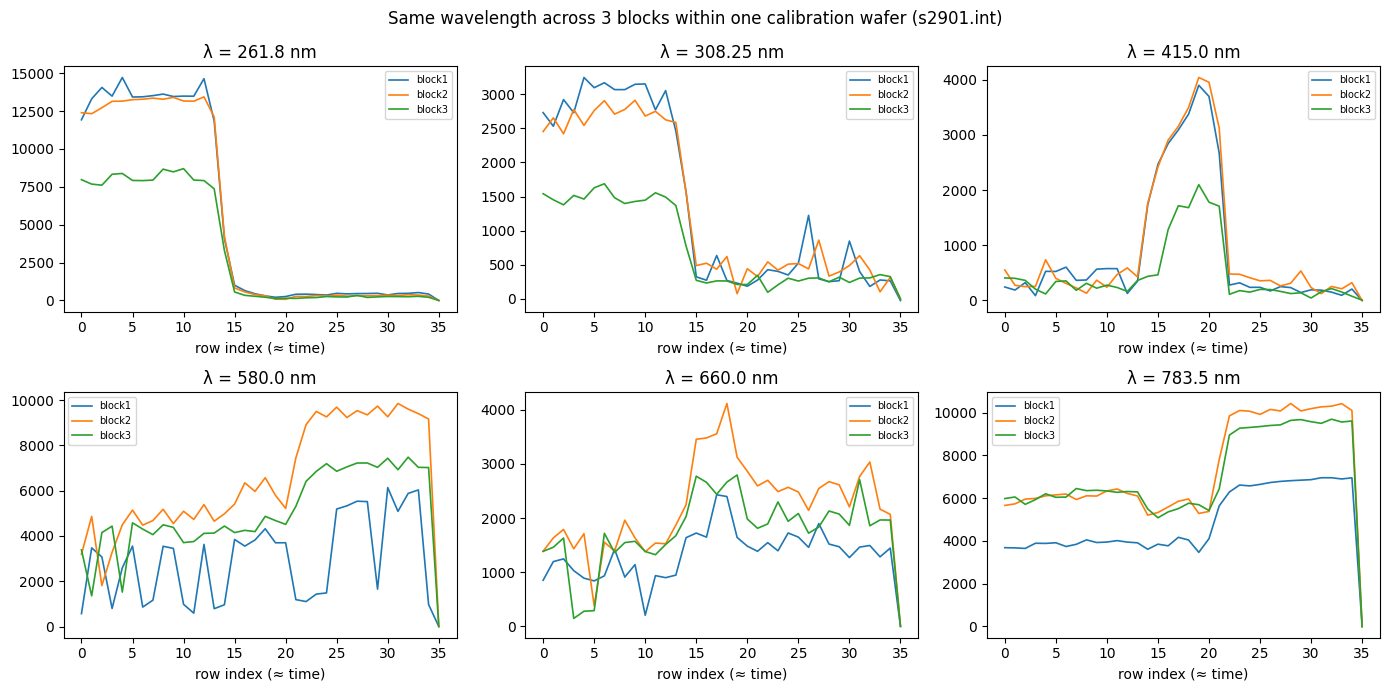

In [3]:
# 한 정상 웨이퍼 안에서 같은 파장이 3블록에서 어떻게 다르게/같이 움직이는지
sample_wafer = df_o.loc[cal_mask_o, 'wafer_names'].iloc[0]
w = df_o[df_o['wafer_names'] == sample_wafer].reset_index(drop=True)

show_wl = [261.8, 308.25, 415.0, 580.0, 660.0, 783.5]   # 대표 파장 6개
fig, axes = plt.subplots(2, 3, figsize=(14, 7)); axes = axes.ravel()
for ax, wl in zip(axes, show_wl):
    i = wavelengths.index(wl)
    ax.plot(w[B1[i]].values, label='block1', lw=1.2)
    ax.plot(w[B2[i]].values, label='block2', lw=1.2)
    ax.plot(w[B3[i]].values, label='block3', lw=1.2)
    ax.set_title(f'λ = {wl} nm')
    ax.set_xlabel('row index (≈ time)')
    ax.legend(fontsize=7)
fig.suptitle(f'Same wavelength across 3 blocks within one calibration wafer ({sample_wafer})')
plt.tight_layout(); plt.show()

In [4]:
K_o = 38
grid_o = np.linspace(0, 1, K_o)

wafers_o, labels_o, blocks = [], [], []
for name, g in df_o.groupby('wafer_names', sort=False):
    n = len(g)
    tn = np.linspace(0, 1, n)                          # 행 인덱스를 0~1로 정규화 (TIME 부재)
    mat = np.column_stack([np.interp(grid_o, tn, g[c].values) for c in wl_all])
    mat = np.log1p(mat)                                # OES 강도 → 로그 변환
    blocks.append(mat); wafers_o.append(name); labels_o.append(g['fault_name'].iloc[0])

tensor_o = np.stack(blocks)                            # (126, 38, 129)
label_o  = pd.Series(labels_o, index=wafers_o, name='fault_name')

print("3D 텐서:", tensor_o.shape, "(웨이퍼 × 시점 × 파장채널)")
print(f"로그 변환 후 값 범위: {tensor_o.min():.2f} ~ {tensor_o.max():.2f}")
print("정상:", int((label_o=='calibration').sum()), "| 이상:", int((label_o!='calibration').sum()))

/tmp/ipykernel_5622/1071334992.py:9: RuntimeWarning: divide by zero encountered in log1p
  mat = np.log1p(mat)                                # OES 강도 → 로그 변환
/tmp/ipykernel_5622/1071334992.py:9: RuntimeWarning: invalid value encountered in log1p
  mat = np.log1p(mat)                                # OES 강도 → 로그 변환


3D 텐서: (126, 38, 129) (웨이퍼 × 시점 × 파장채널)
로그 변환 후 값 범위: nan ~ nan
정상: 106 | 이상: 20


In [5]:
# 파장-major: 같은 파장의 38개 시점이 연속 컬럼이 되도록
feat_cols_o = [f"{wl}_t{k:02d}" for wl in wl_all for k in range(K_o)]
X_o = tensor_o.transpose(0, 2, 1).reshape(tensor_o.shape[0], -1)   # (126, 129*38=4902)
X_o_df = pd.DataFrame(X_o, index=wafers_o, columns=feat_cols_o)
X_o_df.index.name = 'wafer_names'

cal_idx_o = label_o[label_o == 'calibration'].index
mu_o = X_o_df.loc[cal_idx_o].mean()
sd_o = X_o_df.loc[cal_idx_o].std().replace(0, 1)
X_o_z = (X_o_df - mu_o) / sd_o                          # 정상 기준 autoscale

print("펼친 행렬:", X_o_df.shape, "  (웨이퍼 × (파장채널×시점))")
print(f"정상 웨이퍼 {len(cal_idx_o)}장 기준 autoscale 완료")

펼친 행렬: (126, 4902)   (웨이퍼 × (파장채널×시점))
정상 웨이퍼 106장 기준 autoscale 완료


In [6]:
def lag1_autocorr(x):
    x = x - x.mean()
    denom = (x**2).sum()
    return float((x[:-1]*x[1:]).sum()/denom) if denom > 0 else 0.0

fault_idx_o = label_o[label_o != 'calibration'].index
rows = []
for wl in wl_all:                                       # 129개 채널 (43파장 × 3블록)
    cols = [f"{wl}_t{k:02d}" for k in range(K_o)]
    ac   = np.mean([lag1_autocorr(X_o_df.loc[w, cols].values) for w in cal_idx_o])
    fr   = X_o_z.loc[fault_idx_o, cols].abs().mean().mean()
    rows.append({'channel': wl, 'autocorr': round(ac, 3), 'fault_response': round(fr, 3)})

decision_o = pd.DataFrame(rows).set_index('channel')
decision_o['verdict'] = np.where(
    (decision_o['autocorr'] < 0.35) & (decision_o['fault_response'] < 1.0), '제거후보',
    np.where(decision_o['fault_response'] >= 1.5, '강한신호유지', '유지'))

print("=== 제거후보 (정상=노이즈 + 이상에도 둔감) ===")
print(decision_o[decision_o['verdict']=='제거후보'].sort_values('fault_response'))
print(f"\n=== 강한 신호 채널 Top 12 (이상에 ≥1.5σ 반응) ===")
print(decision_o[decision_o['verdict']=='강한신호유지']
      .sort_values('fault_response', ascending=False).head(12))
print("\n요약:", decision_o['verdict'].value_counts().to_dict())

/tmp/ipykernel_5622/3619286588.py:2: RuntimeWarning: invalid value encountered in subtract
  x = x - x.mean()
/tmp/ipykernel_5622/3619286588.py:2: RuntimeWarning: invalid value encountered in subtract
  x = x - x.mean()
/tmp/ipykernel_5622/3619286588.py:2: RuntimeWarning: invalid value encountered in subtract
  x = x - x.mean()
/tmp/ipykernel_5622/3619286588.py:2: RuntimeWarning: invalid value encountered in subtract
  x = x - x.mean()
/tmp/ipykernel_5622/3619286588.py:2: RuntimeWarning: invalid value encountered in subtract
  x = x - x.mean()
/tmp/ipykernel_5622/3619286588.py:2: RuntimeWarning: invalid value encountered in subtract
  x = x - x.mean()
/tmp/ipykernel_5622/3619286588.py:2: RuntimeWarning: invalid value encountered in subtract
  x = x - x.mean()
/tmp/ipykernel_5622/3619286588.py:2: RuntimeWarning: invalid value encountered in subtract
  x = x - x.mean()
/tmp/ipykernel_5622/3619286588.py:2: RuntimeWarning: invalid value encountered in subtract
  x = x - x.mean()
/tmp/ipyke

=== 제거후보 (정상=노이즈 + 이상에도 둔감) ===
         autocorr  fault_response verdict
channel                                  
556.7       0.030           0.660    제거후보
660.0       0.016           0.674    제거후보
660.0.1     0.016           0.686    제거후보
660.0.2     0.010           0.689    제거후보
288.25      0.041           0.716    제거후보
...           ...             ...     ...
670.6.1     0.016           0.956    제거후보
639.7.1     0.025           0.960    제거후보
613.9.1     0.024           0.967    제거후보
787.5.1     0.008           0.973    제거후보
781.0.2     0.008           0.984    제거후보

[82 rows x 3 columns]

=== 강한 신호 채널 Top 12 (이상에 ≥1.5σ 반응) ===
         autocorr  fault_response verdict
channel                                  
250.0       0.075             inf  강한신호유지
261.8       0.034             inf  강한신호유지
308.25      0.016             inf  강한신호유지
324.8       0.037             inf  강한신호유지
580.0       0.040             inf  강한신호유지
613.9       0.008             inf  강한신호유지
639.7       0.008      

In [7]:
raw = df_o[wl_all].values
print("=== 원본 OES 음수 점검 ===")
print(f"전체 셀: {raw.size:,}")
print(f"음수 셀: {(raw < 0).sum():,}  ({(raw<0).sum()/raw.size*100:.2f}%)")
print(f"-1 이하 셀: {(raw <= -1).sum():,}  (이게 NaN의 직접 원인)")
print(f"값 최소/최대: {raw.min():.2f} / {raw.max():.2f}")
print(f"음수 셀이 1개라도 있는 컬럼: {(raw < 0).any(axis=0).sum()} / {len(wl_all)}")

=== 원본 OES 음수 점검 ===
전체 셀: 617,394
음수 셀: 96,626  (15.65%)
-1 이하 셀: 93,112  (이게 NaN의 직접 원인)
값 최소/최대: -593.40 / 131434.20
음수 셀이 1개라도 있는 컬럼: 129 / 129


In [8]:
K_o = 38
grid_o = np.linspace(0, 1, K_o)

wafers_o, labels_o, blocks = [], [], []
for name, g in df_o.groupby('wafer_names', sort=False):
    n = len(g)
    tn  = np.linspace(0, 1, n)
    mat = np.column_stack([np.interp(grid_o, tn, g[c].values) for c in wl_all])
    mat = np.clip(mat, 0, None)        # 음수는 측정 노이즈 → 0으로 클립
    mat = np.log1p(mat)                # 이제 안전: log1p(≥0) = ≥0
    blocks.append(mat); wafers_o.append(name); labels_o.append(g['fault_name'].iloc[0])

tensor_o = np.stack(blocks)
label_o  = pd.Series(labels_o, index=wafers_o, name='fault_name')

assert not np.isnan(tensor_o).any(), "NaN이 아직 남아있음 — 원인 추가 점검 필요"
print("3D 텐서:", tensor_o.shape)
print(f"NaN 셀: {int(np.isnan(tensor_o).sum())}  (0이어야 정상)")
print(f"로그 변환 후 값 범위: {tensor_o.min():.2f} ~ {tensor_o.max():.2f}")
print("정상:", int((label_o=='calibration').sum()), "| 이상:", int((label_o!='calibration').sum()))

3D 텐서: (126, 38, 129)
NaN 셀: 0  (0이어야 정상)
로그 변환 후 값 범위: 0.00 ~ 11.79
정상: 106 | 이상: 20


In [9]:
feat_cols_o = [f"{wl}_t{k:02d}" for wl in wl_all for k in range(K_o)]
X_o = tensor_o.transpose(0, 2, 1).reshape(tensor_o.shape[0], -1)
X_o_df = pd.DataFrame(X_o, index=wafers_o, columns=feat_cols_o)
X_o_df.index.name = 'wafer_names'

cal_idx_o = label_o[label_o == 'calibration'].index
mu_o = X_o_df.loc[cal_idx_o].mean()
sd_o = X_o_df.loc[cal_idx_o].std().replace(0, 1).fillna(1)   # 0과 NaN 모두 1로
X_o_z = (X_o_df - mu_o) / sd_o

# 안전 점검
print("X_o_df  NaN:", int(X_o_df.isna().sum().sum()))
print("X_o_z   NaN:", int(X_o_z.isna().sum().sum()), "| inf:", int(np.isinf(X_o_z.values).sum()))
print("펼친 행렬:", X_o_df.shape)

X_o_df  NaN: 0
X_o_z   NaN: 0 | inf: 0
펼친 행렬: (126, 4902)


In [10]:
def lag1_autocorr(x):
    x = np.asarray(x, dtype=float)
    if not np.all(np.isfinite(x)): return np.nan
    x = x - x.mean()
    denom = (x*x).sum()
    return float((x[:-1]*x[1:]).sum()/denom) if denom > 1e-12 else 0.0

fault_idx_o = label_o[label_o != 'calibration'].index
rows = []
for wl in wl_all:
    cols = [f"{wl}_t{k:02d}" for k in range(K_o)]
    acs  = [lag1_autocorr(X_o_df.loc[w, cols].values) for w in cal_idx_o]
    ac   = float(np.nanmean(acs))
    fr   = float(X_o_z.loc[fault_idx_o, cols].abs().mean().mean())
    rows.append({'channel': wl, 'autocorr': round(ac,3), 'fault_response': round(fr,3)})

decision_o = pd.DataFrame(rows).set_index('channel')
decision_o['verdict'] = np.where(
    (decision_o['autocorr'] < 0.35) & (decision_o['fault_response'] < 1.0), '제거후보',
    np.where(decision_o['fault_response'] >= 1.5, '강한신호유지', '유지'))

print("=== 제거후보 ===")
print(decision_o[decision_o['verdict']=='제거후보'].sort_values('fault_response').head(15))
print("\n=== 강한신호 Top 12 ===")
print(decision_o[decision_o['verdict']=='강한신호유지']
      .sort_values('fault_response', ascending=False).head(12))
print("\n요약:", decision_o['verdict'].value_counts().to_dict())

=== 제거후보 ===
Empty DataFrame
Columns: [autocorr, fault_response, verdict]
Index: []

=== 강한신호 Top 12 ===
Empty DataFrame
Columns: [autocorr, fault_response, verdict]
Index: []

요약: {'유지': 129}


In [11]:
K_o = 38
grid_o = np.linspace(0, 1, K_o)

wafers_o, labels_o, blocks = [], [], []
for name, g in df_o.groupby('wafer_names', sort=False):
    n = len(g)
    tn  = np.linspace(0, 1, n)
    mat = np.column_stack([np.interp(grid_o, tn, g[c].values) for c in wl_all])
    # 로그/클립 없음 — 배경 보정된 신호의 부호와 스케일을 그대로 보존, autoscale에 맡김
    blocks.append(mat); wafers_o.append(name); labels_o.append(g['fault_name'].iloc[0])

tensor_o = np.stack(blocks)
label_o  = pd.Series(labels_o, index=wafers_o, name='fault_name')

print("3D 텐서:", tensor_o.shape)
print(f"NaN 셀: {int(np.isnan(tensor_o).sum())}")
print(f"값 범위: {tensor_o.min():.1f} ~ {tensor_o.max():.1f}")
print("정상:", int((label_o=='calibration').sum()), "| 이상:", int((label_o!='calibration').sum()))

3D 텐서: (126, 38, 129)
NaN 셀: 0
값 범위: -593.4 ~ 131434.2
정상: 106 | 이상: 20


In [13]:
def lag1_autocorr(x):
    x = np.asarray(x, dtype=float)
    if not np.all(np.isfinite(x)): return np.nan
    x = x - x.mean()
    denom = (x*x).sum()
    return float((x[:-1]*x[1:]).sum()/denom) if denom > 1e-12 else 0.0

fault_idx_o = label_o[label_o != 'calibration'].index
rows = []
for wl in wl_all:
    cols = [f"{wl}_t{k:02d}" for k in range(K_o)]
    ac   = float(np.nanmean([lag1_autocorr(X_o_df.loc[w, cols].values) for w in cal_idx_o]))
    fr   = float(X_o_z.loc[fault_idx_o, cols].abs().mean().mean())
    rows.append({'channel': wl, 'autocorr': round(ac,3), 'fault_response': round(fr,3)})
decision_o = pd.DataFrame(rows).set_index('channel')

# 먼저 분포를 본다 - 임계값 결정용
print("=== autocorr 분포 ===")
print(decision_o['autocorr'].describe(percentiles=[.1,.25,.5,.75,.9]).round(3))
print("\n=== fault_response 분포 ===")
print(decision_o['fault_response'].describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).round(3))

# 분포 기준 임계값 자동 설정 (RFM처럼 고정값이 아니라 데이터에 맞춤)
ac_thr = 0.35
fr_low  = decision_o['fault_response'].quantile(0.20)   # 하위 20% = 둔감
fr_high = decision_o['fault_response'].quantile(0.80)   # 상위 20% = 강한 신호
print(f"\n적용 임계값: autocorr<{ac_thr}, fault_response<{fr_low:.2f}(둔감) / ≥{fr_high:.2f}(강한신호)")

decision_o['verdict'] = np.where(
    (decision_o['autocorr'] < ac_thr) & (decision_o['fault_response'] < fr_low), '제거후보',
    np.where(decision_o['fault_response'] >= fr_high, '강한신호', '유지'))

print("\n=== 제거후보 (정상=노이즈 + 이상에도 둔감) ===")
print(decision_o[decision_o['verdict']=='제거후보'].sort_values('fault_response').head(15))
print("\n=== 강한신호 Top 12 (이상에 가장 강하게 반응) ===")
print(decision_o[decision_o['verdict']=='강한신호'].sort_values('fault_response', ascending=False).head(12))
print("\n요약:", decision_o['verdict'].value_counts().to_dict())

=== autocorr 분포 ===
count    129.000
mean       0.839
std        0.025
min        0.755
10%        0.797
25%        0.836
50%        0.846
75%        0.848
90%        0.864
max        0.894
Name: autocorr, dtype: float64

=== fault_response 분포 ===
count    129.000
mean       0.900
std        0.139
min        0.628
10%        0.770
25%        0.814
50%        0.854
75%        0.967
90%        1.128
95%        1.162
99%        1.290
max        1.336
Name: fault_response, dtype: float64

적용 임계값: autocorr<0.35, fault_response<0.81(둔감) / ≥0.99(강한신호)

=== 제거후보 (정상=노이즈 + 이상에도 둔감) ===
Empty DataFrame
Columns: [autocorr, fault_response, verdict]
Index: []

=== 강한신호 Top 12 (이상에 가장 강하게 반응) ===
         autocorr  fault_response verdict
channel                                  
725.0       0.846           1.336    강한신호
791.5.1     0.847           1.310    강한신호
725.0.1     0.847           1.238    강한신호
791.5       0.847           1.227    강한신호
753.7       0.847           1.196    강한신호
753.7.2     0.

/tmp/ipykernel_5622/1537705531.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


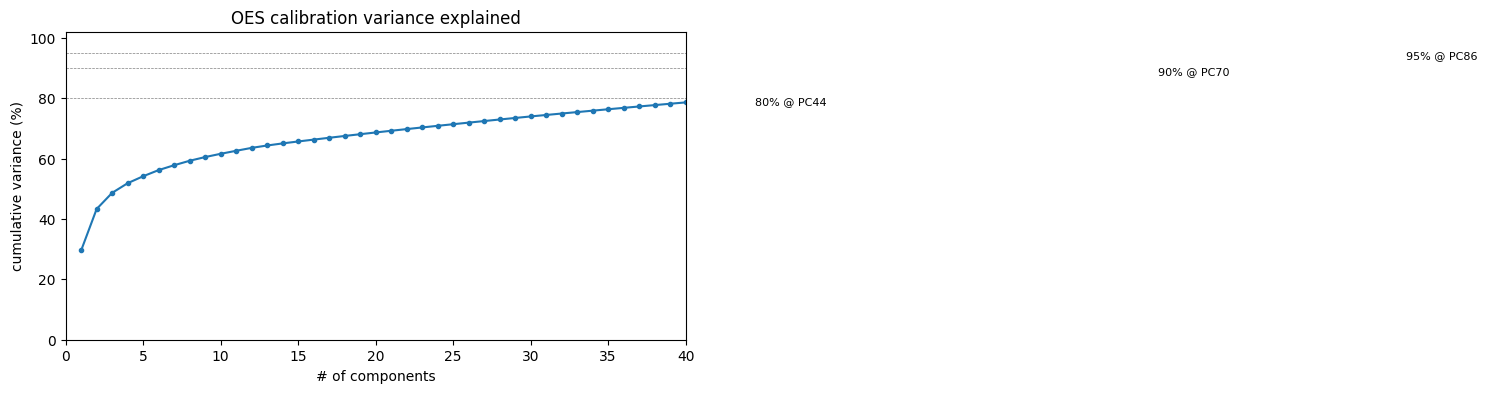

선택된 주성분 수 A_o = 70  (정상 분산 90% 설명)
PC1 단독 설명력: 29.6%


In [14]:
from sklearn.decomposition import PCA

X_o_cal = X_o_z.loc[cal_idx_o].values
pca_o_full = PCA().fit(X_o_cal)
cum_o = np.cumsum(pca_o_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cum_o)+1), cum_o*100, 'o-', ms=3)
for thr in [80, 90, 95]:
    n = int(np.searchsorted(cum_o, thr/100)) + 1
    ax.axhline(thr, color='gray', ls='--', lw=.5)
    ax.text(n+0.5, thr-2, f"{thr}% @ PC{n}", fontsize=8)
ax.set_xlabel('# of components'); ax.set_ylabel('cumulative variance (%)')
ax.set_xlim(0, 40); ax.set_ylim(0, 102)
ax.set_title('OES calibration variance explained')
plt.tight_layout(); plt.show()

A_o = int(np.searchsorted(cum_o, 0.90)) + 1   # RFM과 같은 90% 기준
print(f"선택된 주성분 수 A_o = {A_o}  (정상 분산 90% 설명)")
print(f"PC1 단독 설명력: {pca_o_full.explained_variance_ratio_[0]*100:.1f}%")

한계선: T² > 103.73, Q > 1031.43
탐지 20/20  |  정상 오탐 4/106

=== 이상 웨이퍼별 탐지 결과 (Q 큰 순) ===
   fault     T2        Q  T2_hit  Q_hit  any_hit
   Pr +3 568.73 52593.00    True   True     True
   Pr +2 549.70 51571.59    True   True     True
   Pr -2  48.13  4175.14   False   True     True
   Pr +1  21.75  4101.44   False   True     True
 TCP +50  62.93  4066.64   False   True     True
BCl3 +10  12.95  3505.51   False   True     True
 TCP +30  30.25  3095.25   False   True     True
 Cl2 -10  24.81  2835.90   False   True     True
 TCP -20  10.73  2651.78   False   True     True
 TCP +20  23.29  2630.39   False   True     True
 TCP -15  16.82  2588.02   False   True     True
  RF -12   8.56  2486.87   False   True     True
 TCP +10  10.10  2451.05   False   True     True
  Cl2 +5  22.77  2346.73   False   True     True
 BCl3 -5   8.92  2289.59   False   True     True
  Cl2 -5   9.81  2088.52   False   True     True
   RF +8   5.56  2069.14   False   True     True
 BCl3 +5   5.45  1948.97   False

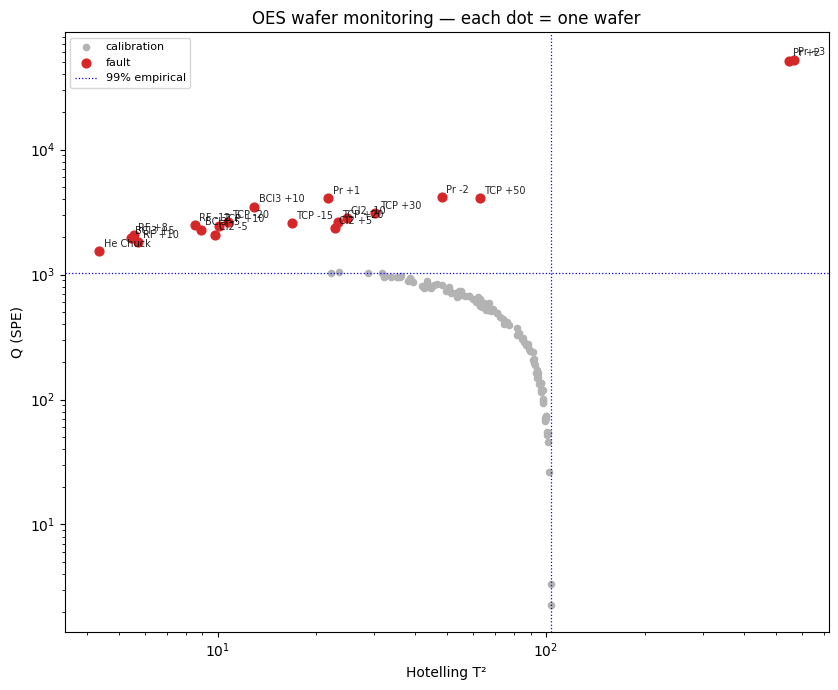

In [15]:
pca_o = PCA(n_components=A_o).fit(X_o_cal)
T_o   = pca_o.transform(X_o_z.values)
res_o = X_o_z.values - pca_o.inverse_transform(T_o)
T2_o  = (T_o**2 / pca_o.explained_variance_).sum(axis=1)
Q_o   = (res_o**2).sum(axis=1)

is_fault_o = (label_o != 'calibration').values
T2_lim_o = np.quantile(T2_o[~is_fault_o], 0.99)
Q_lim_o  = np.quantile(Q_o [~is_fault_o], 0.99)
hit_o = (T2_o > T2_lim_o) | (Q_o > Q_lim_o)

# 이상 유형별 표
ft_o = pd.DataFrame({
    'fault': label_o.values, 'T2': T2_o.round(2), 'Q': Q_o.round(2),
    'T2_hit': T2_o > T2_lim_o, 'Q_hit': Q_o > Q_lim_o, 'any_hit': hit_o,
}, index=label_o.index)
ft_o = ft_o[ft_o['fault']!='calibration'].sort_values('Q', ascending=False)

print(f"한계선: T² > {T2_lim_o:.2f}, Q > {Q_lim_o:.2f}")
print(f"탐지 {int(hit_o[is_fault_o].sum())}/20  |  정상 오탐 {int(hit_o[~is_fault_o].sum())}/106")
print("\n=== 이상 웨이퍼별 탐지 결과 (Q 큰 순) ===")
print(ft_o[['fault','T2','Q','T2_hit','Q_hit','any_hit']].to_string(index=False))

# T²-Q 산점도
fig, ax = plt.subplots(figsize=(8.5, 7))
ax.scatter(T2_o[~is_fault_o], Q_o[~is_fault_o], s=20, c='0.7', label='calibration')
ax.scatter(T2_o[is_fault_o],  Q_o[is_fault_o],  s=40, c='#d62728', label='fault')
for i in np.where(is_fault_o)[0]:
    ax.annotate(label_o.iloc[i], (T2_o[i], Q_o[i]), fontsize=7,
                xytext=(3,3), textcoords='offset points', alpha=.85)
ax.axvline(T2_lim_o, color='b', ls=':', lw=.9, label='99% empirical')
ax.axhline(Q_lim_o,  color='b', ls=':', lw=.9)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Hotelling T²'); ax.set_ylabel('Q (SPE)')
ax.set_title('OES wafer monitoring — each dot = one wafer')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

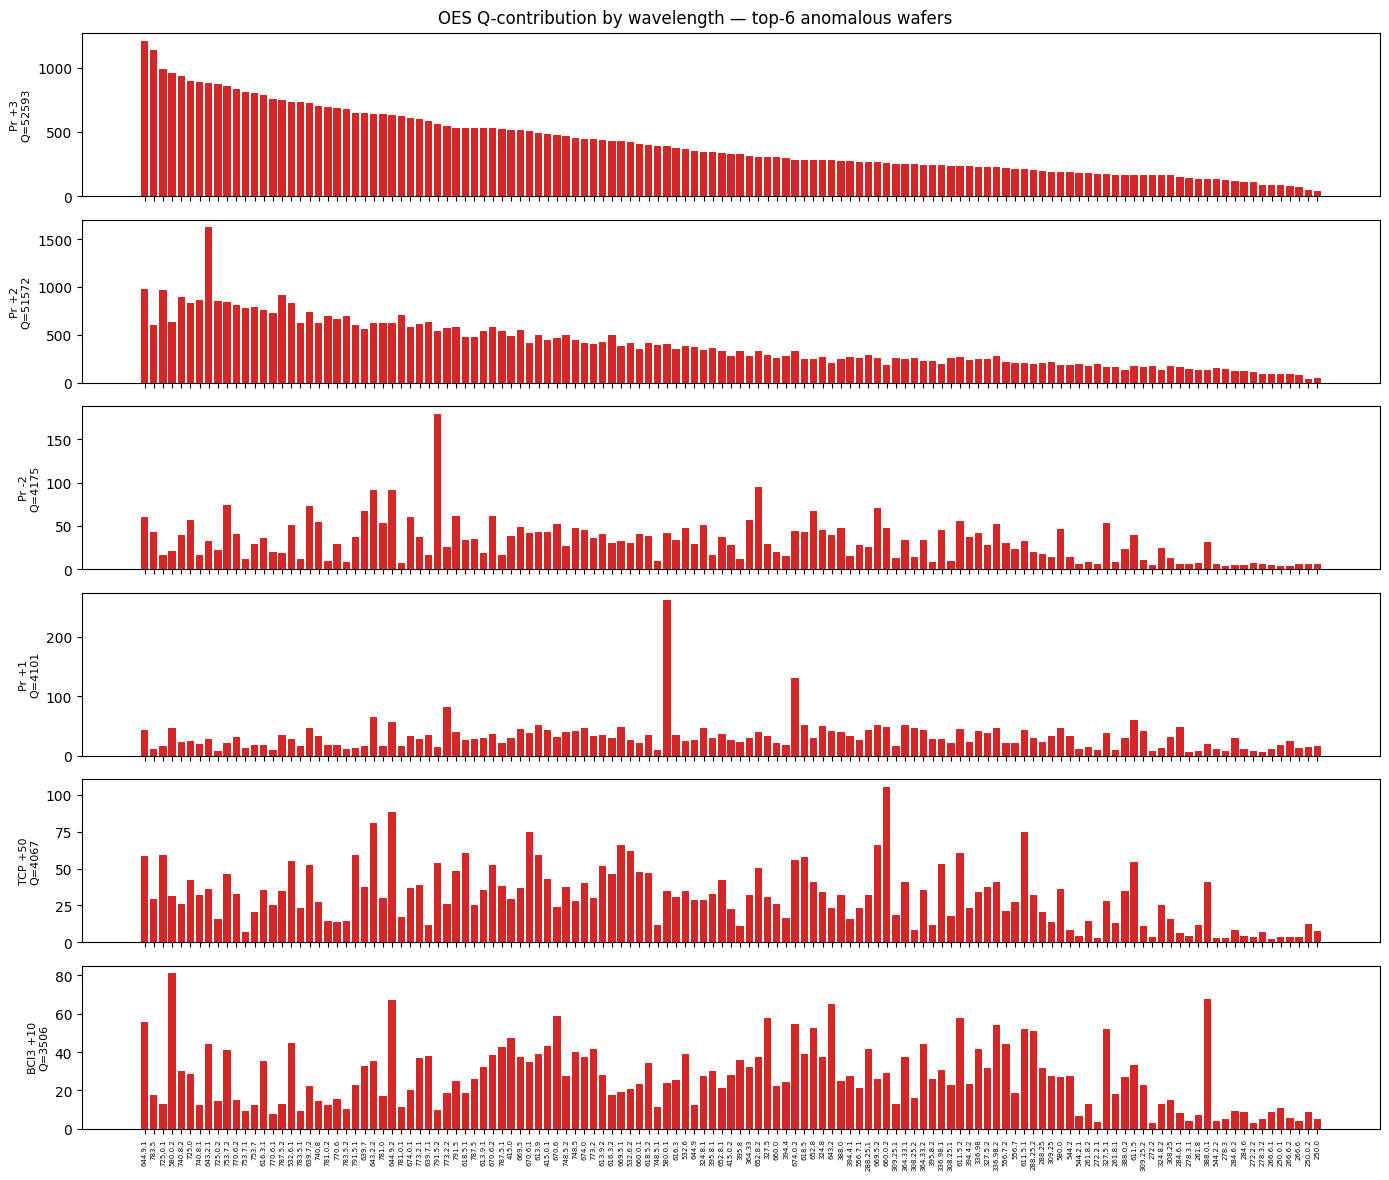


=== 각 이상 웨이퍼의 Top 5 기여 파장 ===
     Pr +3  Q=  52593  ->  644.9.1(1211), 783.5(1139), 725.0.1(993), 580.0.2(959), 740.8.2(933)
     Pr +2  Q=  51572  ->  643.2.1(1623), 644.9.1(976), 725.0.1(963), 787.5.2(912), 740.8.2(891)
     Pr -2  Q=   4175  ->  791.5.2(179), 652.8.2(95), 644.9.2(92), 643.2.2(92), 753.7.2(74)
     Pr +1  Q=   4101  ->  580.0.1(262), 674.0.2(131), 773.2.2(82), 643.2.2(65), 611.5(61)
   TCP +50  Q=   4067  ->  660.0.2(105), 644.9.2(88), 643.2.2(81), 611.5.1(75), 670.6.1(75)
  BCl3 +10  Q=   3506  ->  580.0.2(81), 388.0.1(68), 644.9.2(67), 643.2(65), 670.6(59)


In [16]:
# 상위 6개 이상 웨이퍼의 채널별 Q 기여도
fault_pos_o = np.where(is_fault_o)[0]
top6_o = fault_pos_o[np.argsort(Q_o[fault_pos_o])[-6:][::-1]]

def channel_contrib(row_resid):
    sq = pd.Series(row_resid**2, index=feat_cols_o)
    return sq.groupby(lambda c: c.rsplit('_t', 1)[0]).sum()

ch_order = channel_contrib(res_o[top6_o[0]]).sort_values(ascending=False).index

fig, axes = plt.subplots(6, 1, figsize=(14, 12), sharex=True)
for ax, i in zip(axes, top6_o):
    c = channel_contrib(res_o[i]).reindex(ch_order).fillna(0)
    ax.bar(range(len(c)), c.values, color='#d62728')
    ax.set_ylabel(f"{label_o.iloc[i]}\nQ={Q_o[i]:.0f}", fontsize=8)
axes[-1].set_xticks(range(len(ch_order)))
axes[-1].set_xticklabels(ch_order, rotation=90, fontsize=5)
fig.suptitle('OES Q-contribution by wavelength — top-6 anomalous wafers')
plt.tight_layout(); plt.show()

# 각 fault의 Top 5 기여 파장 텍스트로
print("\n=== 각 이상 웨이퍼의 Top 5 기여 파장 ===")
for i in top6_o:
    c = channel_contrib(res_o[i]).sort_values(ascending=False).head(5)
    top5 = ", ".join([f"{wl}({v:.0f})" for wl, v in c.items()])
    print(f"{label_o.iloc[i]:>10s}  Q={Q_o[i]:>7.0f}  ->  {top5}")

In [17]:
# RFM과 같은 형식으로 저장
X_o_z.to_csv('oes_block_features.csv')        # 웨이퍼명 × 4902 (autoscaled)

scores_o = pd.DataFrame({
    'fault_name': label_o.values,
    'T2_oes': T2_o, 'Q_oes': Q_o, 'hit_oes': hit_o,
}, index=label_o.index)
scores_o.index.name = 'wafer_names'
scores_o.to_csv('oes_block_scores.csv')

print(f"저장 완료:")
print(f"  oes_block_features.csv  {X_o_z.shape}")
print(f"  oes_block_scores.csv    탐지 {int(hit_o[is_fault_o].sum())}/20, 오탐 {int(hit_o[~is_fault_o].sum())}/106")

from google.colab import files
files.download('oes_block_features.csv')
files.download('oes_block_scores.csv')

저장 완료:
  oes_block_features.csv  (126, 4902)
  oes_block_scores.csv    탐지 20/20, 오탐 4/106


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>